In [ ]:
!wget https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/helper_functions.py

--2025-06-19 08:33:46--  https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17619 (17K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  17.21K  --.-KB/s    in 0.001s  

2025-06-19 08:33:46 (31.6 MB/s) - ‘helper_functions.py’ saved [17619/17619]



In [ ]:
from helper_functions import unzip_data,create_tensorboard_callback,plot_loss_curves,compare_historys,make_confusion_matrix,calculate_results

In [ ]:
!wget "https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip"

unzip_data("nlp_getting_started.zip")

--2025-06-19 08:33:50--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.01s   

2025-06-19 08:33:50 (51.1 MB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



In [ ]:
import pandas as pd
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
train_df_shuffled=train_df.sample(frac=1,random_state=42)
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [ ]:
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [ ]:
len(train_df)

7613

In [ ]:
len(test_df)

3263

In [ ]:
train_df.target.value_counts()

,count
target,
0,4342
1,3271


In [ ]:
import random
random_index=random.randint(0,len(train_df)-5)
for row in train_df_shuffled[["text","target"]][random_index:random_index+5].itertuples():
  _,text,target=row
  print(f"Target:{target}","(real diaster)" if target>0 else "(not real diaster)")
  print(f"Text:\n{text}\n")
  print(f"---\n")

Target:1 (real diaster)
Text:
I WAS PEACEFULLY SITTING IN MY ROOM AND I HEARD THIS LOUD BANG OF SOMETHING FALLING

---

Target:0 (not real diaster)
Text:
catastrophic-fallen-angel: reveillertm: macabrelolita: I was supposed to write Û÷amino acidsÛª and I nearly... http://t.co/dIoBzGHFju

---

Target:0 (not real diaster)
Text:
'if you can't summon the flames directly from hell store bought is fine'-me 
mom-*dies*

---

Target:0 (not real diaster)
Text:
Back in 02 to 03 would never said that 50 would have ended ja like obliteration

---

Target:0 (not real diaster)
Text:
How can we help save a beautiful town in Ontario from destruction by a power plant developer?
http://t.co/hlD5xLYwBn

---



In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
train_sentences,val_sentences,train_label,val_label=train_test_split(train_df_shuffled["text"].to_numpy(),
                                                                     train_df_shuffled["target"].to_numpy(),
                                                                     test_size=0.1,random_state=42)

In [ ]:
len(train_sentences),len(val_sentences),len(train_label),len(val_label)

(6851, 762, 6851, 762)

In [ ]:
train_sentences[:10],train_label[:10]

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [ ]:
text_vectorizer = TextVectorization(
    max_tokens=None,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    ngrams=None,
    output_mode="int"
)


In [ ]:
max_vocab_length = 10000
max_length = 15

text_vectorizer = TextVectorization(
    max_tokens=max_vocab_length,
    output_mode="int",
    output_sequence_length=max_length
)


In [ ]:
text_vectorizer.adapt(train_sentences)

In [ ]:
sample_sentence="There's a flood in my street"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[264,   3, 232,   4,  13, 698,   0,   0,   0,   0,   0,   0,   0,
          0,   0]])>

In [ ]:
random_sentence=random.choice(train_sentences)
print(f"original text:\n{random_sentence}\
        \n\nVectorized version:")
text_vectorizer([random_sentence])

original text:
Vassalboro house to be razed to make way for public gazebo @PeteL_McGuire reports. http://t.co/uUEwccdTow        

Vectorized version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[7072,  318,    5,   21,  477,    5,  144,  147,   10,  926,    1,
        9833,  923,    1,    0]])>

In [ ]:
words_in_vocab=text_vectorizer.get_vocabulary()
top_10_words=words_in_vocab[:10]
print(f"top 10 word{top_10_words}")
bottom_10_words=words_in_vocab[-10:]
print(f"top 10 word{bottom_10_words}")

top 10 word['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('in'), np.str_('to'), np.str_('of'), np.str_('and'), np.str_('i'), np.str_('is')]
top 10 word[np.str_('painthey'), np.str_('painful'), np.str_('paine'), np.str_('paging'), np.str_('pageshi'), np.str_('pages'), np.str_('paeds'), np.str_('pads'), np.str_('padres'), np.str_('paddytomlinson1')]


In [ ]:
len(words_in_vocab)

10000

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

embedding = layers.Embedding(
    input_dim=max_vocab_length,
    output_dim=128,
    embeddings_initializer="uniform",
    input_length=max_length
)

embedding


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [ ]:
random_sentence=random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\
      \n\nEmbedded version:")
sample_embed=embedding(text_vectorizer([random_sentence]))
sample_embed

Original text:
We are getting some reports of flooding near Jonesboro High School. Please use caution when driving in the area. Turn around don't drown!      

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[-0.0387759 ,  0.02728129, -0.01976388, ...,  0.02891311,
         -0.0247488 , -0.0173737 ],
        [ 0.03485029, -0.00714461,  0.04570593, ..., -0.04131597,
         -0.02075893, -0.0052111 ],
        [ 0.00796451, -0.02712681, -0.03188965, ...,  0.01219145,
         -0.01607697,  0.01410742],
        ...,
        [-0.03048487,  0.04994192, -0.04839045, ...,  0.02238676,
         -0.04551205, -0.03404518],
        [-0.0199339 ,  0.03695288,  0.04758973, ..., -0.02269874,
          0.02383177,  0.00570195],
        [-0.03484454,  0.03092697, -0.04185147, ...,  0.03080953,
         -0.02809766,  0.01998741]]], dtype=float32)>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model0=Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("clf",MultinomialNB())
])

model0.fit(train_sentences,train_label)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [ ]:
baseline_score=model0.score(val_sentences,val_label)
print(f"Our baseline model achieves an accuracy of:{baseline_score*100:.2f}%")

Our baseline model achieves an accuracy of:79.27%


In [ ]:
baseline_preds=model0.predict(val_sentences)
baseline_preds[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [ ]:
baseline_results=calculate_results(y_true=val_label,y_pred=baseline_preds)
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [ ]:
SAVE_DIR="model_logs"
from tensorflow.keras import layers
inputs=layers.Input(shape=(1,),dtype="string")
x=text_vectorizer(inputs)
x=embedding(x)
x = layers.GlobalAveragePooling1D()(x)
outputs=layers.Dense(1,activation="sigmoid")(x)
model1=tf.keras.Model(inputs,outputs,name="model_1_dense")

In [ ]:
model1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,129 (4.88 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])

In [ ]:
history1=model1.fit(x=train_sentences,
                    y=train_label,
                    epochs=5,
                    validation_data=(val_sentences,val_label),
                    callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                           experiment_name="model_1_dense")]
                    )

Saving TensorBoard log files to: model_logs/model_1_dense/20250619-083356
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6394 - loss: 0.6489 - val_accuracy: 0.7507 - val_loss: 0.5375
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8135 - loss: 0.4619 - val_accuracy: 0.7822 - val_loss: 0.4748
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8650 - loss: 0.3507 - val_accuracy: 0.7979 - val_loss: 0.4581
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8888 - loss: 0.2850 - val_accuracy: 0.7900 - val_loss: 0.4642
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9100 - loss: 0.2434 - val_accuracy: 0.7874 - val_loss: 0.4868


In [ ]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [ ]:
model1.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7761 - loss: 0.5233


[0.48681628704071045, 0.787401556968689]

In [ ]:
model1_pred_probs=model1.predict(val_sentences)
model1_pred_probs[0]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([0.3324963], dtype=float32)

In [ ]:
model1_pred_probs.shape

(762, 1)

In [ ]:
model1_pred_probs=tf.squeeze(tf.round(model1_pred_probs))

In [ ]:
model1_pred_probs

<tf.Tensor: shape=(762,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
       0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
       1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0

In [ ]:
val_label

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,

In [ ]:
model1_results=calculate_results(y_true=val_label,y_pred=model1_pred_probs)

In [ ]:
model1_results

{'accuracy': 78.74015748031496,
 'precision': 0.795856216502349,
 'recall': 0.7874015748031497,
 'f1': 0.7833080082089368}

In [ ]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [ ]:
words_in_vocab=text_vectorizer.get_vocabulary()
len(words_in_vocab),words_in_vocab[:10]

(10000,
 ['',
  '[UNK]',
  np.str_('the'),
  np.str_('a'),
  np.str_('in'),
  np.str_('to'),
  np.str_('of'),
  np.str_('and'),
  np.str_('i'),
  np.str_('is')])

In [ ]:
model1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,389 (14.65 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,560,260 (9.77 MB)

In [ ]:
embed_weights=model1.get_layer("embedding").get_weights()

In [ ]:
embed_weights

[array([[ 0.07047032,  0.04085959,  0.00729708, ...,  0.00664461,
         -0.01531353, -0.04341946],
        [-0.03595045, -0.03739624, -0.02958215, ...,  0.03735585,
          0.03194981,  0.01125888],
        [-0.00043474,  0.02179503,  0.02522373, ...,  0.05648267,
          0.04012619, -0.02077959],
        ...,
        [-0.03596268, -0.03962443, -0.04189545, ..., -0.00686741,
          0.03607019,  0.0211443 ],
        [ 0.04241738, -0.04438639,  0.05568016, ...,  0.02617332,
          0.07334188, -0.03518151],
        [ 0.06769528, -0.04006964,  0.10846578, ...,  0.10914514,
          0.05939946, -0.1008475 ]], dtype=float32)]

In [ ]:
embed_weights[0].shape

(10000, 128)

In [ ]:
# # # Code below is adapted from: https://www.tensorflow.org/tutorials/text/word_embeddings#retrieve_the_trained_word_embeddings_and_save_them_to_disk
# import io

# # # Create output writers
# out_v = io.open("embedding_vectors.tsv", "w", encoding="utf-8")
# out_m = io.open("embedding_metadata.tsv", "w", encoding="utf-8")

# # # Write embedding vectors and words to file
# for num, word in enumerate(words_in_vocab):
#   if num == 0:
# #      continue # skip padding token
#    vec = embed_weights[num]
#   out_m.write(word + "\n") # write words to file
#   out_v.write("\t".join([str(x) for x in vec]) + "\n") # write corresponding word vector to file
# out_v.close()
# out_m.close()

# # # Download files locally to upload to Embedding Projector
# # try:
# #   from google.colab import files
# # except ImportError:
# #   pass
# # else:
# #   files.download("embedding_vectors.tsv")
# #   files.download("embedding_metadata.tsv")

In [ ]:
inputs=layers.Input(shape=(1,),dtype="string")
x=text_vectorizer(inputs)
x=embedding(x)
# print(x.shape)
# x=layers.LSTM(64,return_sequences=True)(x)
# print(x.shape)
x=layers.LSTM(64)(x)
# print(x.shape)
# x=layers.Dense(64,activation="relu")(x)
# print(x.shape)
outputs=layers.Dense(1,activation="sigmoid")(x)
model2=tf.keras.Model(inputs,outputs,name="model2_LSTM")

In [ ]:
model2.summary()

Model: "model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])


In [ ]:
history2=model2.fit(x=train_sentences,
                    y=train_label,
                    epochs=5,
                    validation_data=(val_sentences,val_label),
                    callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                           experiment_name="model_2_dense")]
                    )

Saving TensorBoard log files to: model_logs/model_2_dense/20250619-083410
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8960 - loss: 0.2929 - val_accuracy: 0.7835 - val_loss: 0.5740
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9389 - loss: 0.1594 - val_accuracy: 0.7874 - val_loss: 0.5660
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9513 - loss: 0.1297 - val_accuracy: 0.7835 - val_loss: 0.7694
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9621 - loss: 0.1008 - val_accuracy: 0.7743 - val_loss: 0.7692
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9699 - loss: 0.0757 - val_accuracy: 0.7703 - val_loss: 0.9922


In [ ]:
model2.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7559 - loss: 1.0688


[0.992229163646698, 0.7703412175178528]

In [ ]:
model2_pred_probs=model2.predict(val_sentences)
model2_pred_probs[0]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([0.00637277], dtype=float32)

In [ ]:
model2_pred_probs=tf.squeeze(tf.round(model2_pred_probs))

In [ ]:
model2_results=calculate_results(val_label,model2_pred_probs)
model2_results

{'accuracy': 77.03412073490814,
 'precision': 0.7732589791209112,
 'recall': 0.7703412073490814,
 'f1': 0.7676409049388612}

In [ ]:
inputs=layers.Input(shape=(1,),dtype="string")
x=text_vectorizer(inputs)
x=embedding(x)
x=layers.GRU(64)(x)
outputs=layers.Dense(1,activation="sigmoid")(x)
model3=tf.keras.Model(inputs,outputs,name="model3_GRU")

In [ ]:
model3.summary()

Model: "model3_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])

In [ ]:
history3=model3.fit(x=train_sentences,
                    y=train_label,
                    epochs=5,
                    validation_data=(val_sentences,val_label),
                    callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                           experiment_name="model_3_GRU")])

Saving TensorBoard log files to: model_logs/model_3_GRU/20250619-083423
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9034 - loss: 0.2574 - val_accuracy: 0.7651 - val_loss: 0.6937
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9722 - loss: 0.0780 - val_accuracy: 0.7743 - val_loss: 0.8986
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9753 - loss: 0.0678 - val_accuracy: 0.7769 - val_loss: 1.0147
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9770 - loss: 0.0561 - val_accuracy: 0.7717 - val_loss: 1.1050
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9763 - loss: 0.0564 - val_accuracy: 0.7730 - val_loss: 1.1533


In [ ]:
model3.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7482 - loss: 1.2212


[1.1533323526382446, 0.7729659080505371]

In [ ]:
model3_pred_probs=model3.predict(val_sentences)
model3_pred_probs

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[4.51662258e-04],
       [7.41043866e-01],
       [9.99861479e-01],
       [4.98198457e-02],
       [3.09114228e-04],
       [9.99848366e-01],
       [4.94670928e-01],
       [9.99958158e-01],
       [9.99891877e-01],
       [8.10685992e-01],
       [9.59938508e-04],
       [8.41192067e-01],
       [5.66668285e-04],
       [7.74217844e-02],
       [2.89452117e-04],
       [5.67002641e-03],
       [1.79005961e-03],
       [8.91724660e-04],
       [2.24829186e-02],
       [9.99858022e-01],
       [9.99867082e-01],
       [1.78647344e-04],
       [9.99733508e-01],
       [4.63736942e-03],
       [9.99917626e-01],
       [9.99884248e-01],
       [3.51118459e-03],
       [7.46753765e-04],
       [8.08546494e-04],
       [6.56046391e-01],
       [9.99727190e-01],
       [2.55776313e-03],
       [5.24042584e-02],
       [3.29175568e-03],
       [7.87388384e-01],
       [2.02483222e-01],
       [9.99837041e-01],
       [1.97176144e-01],
       [3.48437615e-02],
       [9.99919772e-01],


In [ ]:
model3_pred_probs=tf.squeeze(tf.round(model3_pred_probs))

In [ ]:
model3_pred_probs

<tf.Tensor: shape=(762,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
       1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0

In [ ]:
model3_results=calculate_results(val_label,model3_pred_probs)

In [ ]:
model3_results

{'accuracy': 77.29658792650919,
 'precision': 0.7759760952910788,
 'recall': 0.7729658792650919,
 'f1': 0.7702964374538457}

In [ ]:
inputs=layers.Input(shape=(1,),dtype="string")
x=text_vectorizer(inputs)
x=embedding(x)
x=layers.Bidirectional(layers.LSTM(64))(x)
outputs=layers.Dense(1,activation="sigmoid")(x)
model4=tf.keras.Model(inputs,outputs,name="model4_bidirectional")


In [ ]:
model4.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])

In [ ]:
history4=model4.fit(x=train_sentences,
                    y=train_label,
                    epochs=5,
                    validation_data=(val_sentences,val_label),
                    callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                           experiment_name="model_4_bidir")])

Saving TensorBoard log files to: model_logs/model_4_bidir/20250619-083437
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9514 - loss: 0.1897 - val_accuracy: 0.7717 - val_loss: 0.8963
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9785 - loss: 0.0518 - val_accuracy: 0.7703 - val_loss: 1.0622
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9811 - loss: 0.0428 - val_accuracy: 0.7782 - val_loss: 1.2650
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9786 - loss: 0.0436 - val_accuracy: 0.7703 - val_loss: 1.5950
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9820 - loss: 0.0381 - val_accuracy: 0.7664 - val_loss: 1.3053


In [ ]:
model4.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7384 - loss: 1.4569


[1.3053356409072876, 0.7664042115211487]

In [ ]:
model4_pred_probs=model4.predict(val_sentences)
model4_pred_probs

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


array([[2.63952301e-04],
       [6.84252203e-01],
       [9.99887943e-01],
       [9.75564122e-02],
       [4.07417174e-05],
       [9.99518394e-01],
       [2.07098097e-01],
       [9.99955654e-01],
       [9.99903440e-01],
       [7.66954720e-01],
       [1.03976294e-04],
       [5.07883549e-01],
       [1.28044820e-04],
       [2.33875051e-01],
       [4.19585303e-05],
       [4.63788863e-04],
       [6.80745434e-05],
       [3.73626972e-05],
       [6.37556380e-03],
       [9.98158872e-01],
       [9.99381661e-01],
       [6.10033858e-05],
       [9.99572933e-01],
       [2.72976031e-04],
       [9.99858856e-01],
       [9.99901056e-01],
       [1.68141341e-04],
       [2.67878640e-04],
       [7.24188576e-05],
       [1.95162520e-01],
       [9.95895505e-01],
       [9.24788590e-04],
       [3.43715727e-01],
       [1.15960909e-04],
       [5.81453787e-03],
       [2.10545629e-01],
       [9.99826610e-01],
       [2.05508441e-01],
       [2.48409226e-03],
       [9.99876022e-01],


In [ ]:
model4_pred_probs=tf.squeeze(tf.round(model4_pred_probs))

In [ ]:
model4_results=calculate_results(val_label,model4_pred_probs)
model4_results

{'accuracy': 76.64041994750657,
 'precision': 0.7700415019325116,
 'recall': 0.7664041994750657,
 'f1': 0.7632772796567181}

In [ ]:
inputs=layers.Input(shape=(1,),dtype="string")
x=text_vectorizer(inputs)
x=embedding(x)
x=layers.Conv1D(filters=64,kernel_size=5,activation="relu",padding="valid")(x)
x = layers.GlobalMaxPooling1D()(x)
outputs=layers.Dense(1,activation="sigmoid")(x)
model5=tf.keras.Model(inputs,outputs,name="model5_Conv1d")

In [ ]:
model5.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])

In [ ]:
model5.summary()

Model: "model5_Conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 11, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,089 (5.04 MB)

 Trainable params: 1,321,089 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history5=model5.fit(train_sentences,
                    train_label,
                    epochs=5,
                    validation_data=(val_sentences,val_label),
                    callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                           "Conve1D")])

Saving TensorBoard log files to: model_logs/Conve1D/20250619-083452
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9354 - loss: 0.1912 - val_accuracy: 0.7703 - val_loss: 0.8973
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9741 - loss: 0.0734 - val_accuracy: 0.7690 - val_loss: 1.0696
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9809 - loss: 0.0548 - val_accuracy: 0.7638 - val_loss: 1.1387
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9816 - loss: 0.0483 - val_accuracy: 0.7664 - val_loss: 1.2040
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9839 - loss: 0.0431 - val_accuracy: 0.7625 - val_loss: 1.2522


In [ ]:
model5.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7398 - loss: 1.4306


[1.2522486448287964, 0.7624672055244446]

In [ ]:
model5_pred_probs=model5.predict(val_sentences)
model5_pred_probs

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[9.83220488e-02],
       [9.10806596e-01],
       [9.99940276e-01],
       [2.19145156e-02],
       [2.50097596e-08],
       [9.97199774e-01],
       [9.62213278e-01],
       [9.99991417e-01],
       [9.99998450e-01],
       [7.24278867e-01],
       [1.19445119e-07],
       [9.06967819e-01],
       [5.73266379e-06],
       [1.11883983e-01],
       [2.15046114e-07],
       [3.54866451e-03],
       [4.47876897e-04],
       [9.63819621e-05],
       [7.51871429e-03],
       [9.92890835e-01],
       [7.49252200e-01],
       [1.03171647e-06],
       [9.99566615e-01],
       [4.84383199e-04],
       [9.99992490e-01],
       [1.00000000e+00],
       [2.36880180e-04],
       [3.72930343e-04],
       [2.84301292e-04],
       [4.32017922e-01],
       [2.72992969e-01],
       [4.31632507e-05],
       [7.64548838e-01],
       [7.87412340e-04],
       [1.19770348e-01],
       [5.04584014e-01],
       [9.99995828e-01],
       [1.66868642e-01],
       [1.49751389e-02],
       [9.99995828e-01],


In [ ]:
model5_pred_probs=tf.squeeze(tf.round(model5_pred_probs))
model5_pred_probs

<tf.Tensor: shape=(762,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
       0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1.,
       1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0

In [ ]:
model5_results=calculate_results(val_label,model5_pred_probs)
model5_results

{'accuracy': 76.24671916010499,
 'precision': 0.7637525216162191,
 'recall': 0.7624671916010499,
 'f1': 0.7603795119224995}

In [ ]:
# Example of pretrained embedding with universal sentence encoder - https://tfhub.dev/google/universal-sentence-encoder/4
import tensorflow_hub as hub
embed = hub.load("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2") # load Universal Sentence Encoder
embed_samples = embed([sample_sentence,
                      "When you call the universal sentence encoder on a sentence, it turns it into numbers."])

print(embed_samples[0][:50])

tf.Tensor(
[-0.01157028  0.0248591   0.02878048 -0.012715    0.03971538  0.0882776
  0.02680984  0.05589836 -0.0106873  -0.00597291  0.00639323 -0.01819518
  0.00030813  0.09105888  0.05874644 -0.03180628  0.01512474 -0.05162929
  0.00991367 -0.06865347 -0.04209306  0.02678981  0.03011006  0.00321069
 -0.00337973 -0.04787357  0.0226672  -0.00985925 -0.04063613 -0.01292092
 -0.04666384  0.05630299 -0.03949255  0.00517686  0.02495829 -0.0701444
  0.02871508  0.04947684 -0.00633979 -0.08960192  0.02807118 -0.00808364
 -0.01360602  0.0599865  -0.10361787 -0.05195374  0.00232954 -0.02332531
 -0.03758105  0.03327728], shape=(50,), dtype=float32)


In [ ]:
# url = 'https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2'
url = 'https://tfhub.dev/google/universal-sentence-encoder/4'
universal_encoder = hub.KerasLayer(url,
    input_shape=[],
    dtype=tf.string,
    trainable=False,
    name="USE")

class UniversalEncoderLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return universal_encoder(inputs)


inputs = tf.keras.Input(shape=[], dtype=tf.string)

embedding_vector = UniversalEncoderLayer()(inputs) # Encoder

x= layers.Dense(128, activation='relu', kernel_initializer='he_normal')(embedding_vector)
x= layers.BatchNormalization()(x)  # Normalize activations
x= layers.Dropout(0.5)(x)  # Reduce overfitting
x= layers.Dense(64, activation='relu', kernel_initializer='he_normal')(x)
x= layers.BatchNormalization()(x)
x= layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_normal')(x)

model6= tf.keras.Model(inputs=[inputs], outputs=[output],name="Model_6_USE")
model6.summary()

Model: "Model_6_USE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ universal_encoder_layer         │ (None, 512)            │             0 │
│ (UniversalEncoderLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

 Trainable params: 74,369 (290.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'], jit_compile=False)

history6=model6.fit(train_sentences,
           train_label,
           epochs=5,
           validation_data=(val_sentences,val_label),
           callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                  "TF-USE")])

Saving TensorBoard log files to: model_logs/TF-USE/20250619-083546
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(None,))
  warnings.warn(msg)


215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6799 - loss: 0.6650 - val_accuracy: 0.6942 - val_loss: 0.5845
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7972 - loss: 0.4596 - val_accuracy: 0.8163 - val_loss: 0.4576
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8222 - loss: 0.4244 - val_accuracy: 0.8215 - val_loss: 0.4159
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8297 - loss: 0.3968 - val_accuracy: 0.8150 - val_loss: 0.4218
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8283 - loss: 0.3888 - val_accuracy: 0.8215 - val_loss: 0.4188


In [ ]:
model6.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7960 - loss: 0.4777


[0.41881710290908813, 0.8215222954750061]

In [ ]:
model6_pred_probs=model6.predict(val_sentences)
model6_pred_probs

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(32,))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


array([[0.25648373],
       [0.7092169 ],
       [0.9966634 ],
       [0.08949409],
       [0.47007075],
       [0.8259154 ],
       [0.989198  ],
       [0.99087924],
       [0.97426885],
       [0.08008587],
       [0.5024548 ],
       [0.4475709 ],
       [0.29741853],
       [0.211565  ],
       [0.19875391],
       [0.01820326],
       [0.19467542],
       [0.28698114],
       [0.20214795],
       [0.3355352 ],
       [0.8323143 ],
       [0.09403609],
       [0.43876758],
       [0.02074192],
       [0.8883801 ],
       [0.99767274],
       [0.02184647],
       [0.10194013],
       [0.13408712],
       [0.10783626],
       [0.41664284],
       [0.9533314 ],
       [0.45289236],
       [0.40952766],
       [0.7930694 ],
       [0.09452418],
       [0.9908454 ],
       [0.02422516],
       [0.02486948],
       [0.9820703 ],
       [0.08032963],
       [0.3153708 ],
       [0.28654498],
       [0.25038138],
       [0.14640632],
       [0.9901765 ],
       [0.17945264],
       [0.944

In [ ]:
model6_pred_probs=tf.squeeze(tf.round(model6_pred_probs))

In [ ]:
model6_results=calculate_results(val_label,model6_pred_probs)
model6_results

{'accuracy': 82.1522309711286,
 'precision': 0.8260248375546463,
 'recall': 0.821522309711286,
 'f1': 0.8194798413883178}

In [ ]:
import numpy as np

In [ ]:
# One kind of correct way (there are more) to make data subset
# (split the already split train_sentences/train_labels)
train_sentences_90_percent, train_sentences_10_percent, train_label_90_percent, train_label_10_percent = train_test_split(np.array(train_sentences),
                                                                                                                            train_label,
                                                                                                                            test_size=0.1,
                                                                                                                            random_state=42)


In [ ]:
model7=tf.keras.models.clone_model(model6)
model7.compile(loss='binary_crossentropy',
               optimizer="Adam",
               metrics=['accuracy'],
               jit_compile=False)

history7=model7.fit(train_sentences_10_percent,
           train_label_10_percent,
           epochs=5,
           validation_data=(val_sentences,val_label),
           callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                  "TF-USE")])

Saving TensorBoard log files to: model_logs/TF-USE/20250619-084952
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(None,))
  warnings.warn(msg)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6309 - loss: 0.7300 - val_accuracy: 0.7323 - val_loss: 0.6649
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7443 - loss: 0.5696 - val_accuracy: 0.7362 - val_loss: 0.6559
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8027 - loss: 0.4838 - val_accuracy: 0.7533 - val_loss: 0.6441
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8446 - loss: 0.3785 - val_accuracy: 0.7782 - val_loss: 0.6331
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8544 - loss: 0.3390 - val_accuracy: 0.7953 - val_loss: 0.6202


In [ ]:
model7.evaluate(val_sentences,val_label)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7774 - loss: 0.6249


[0.6202192902565002, 0.7952755689620972]

In [ ]:
model7_pred_probs=model7.predict(val_sentences)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(32,))
  warnings.warn(msg)


22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(None,))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


In [ ]:
model7_pred_probs=tf.squeeze(tf.round(model7_pred_probs))

In [ ]:
model7_results=calculate_results(val_label,model7_pred_probs)
model7_results

{'accuracy': 79.52755905511812,
 'precision': 0.8000930263463902,
 'recall': 0.7952755905511811,
 'f1': 0.792535143968809}

In [ ]:
all_model_results=pd.DataFrame({"baseline":baseline_results,
                                "model1":model1_results,
                                "model2":model2_results,
                                "model3":model3_results,
                                "model4":model4_results,
                                "model5":model5_results,
                                "model6":model6_results,
                                "model7":model7_results
                                })

In [ ]:
all_model_results=all_model_results.transpose()

In [ ]:
all_model_results["accuracy"]=all_model_results["accuracy"]/100
all_model_results

,accuracy,precision,recall,f1
baseline,0.792651,0.811139,0.792651,0.786219
model1,0.787402,0.795856,0.787402,0.783308
model2,0.770341,0.773259,0.770341,0.767641
model3,0.772966,0.775976,0.772966,0.770296
model4,0.766404,0.770042,0.766404,0.763277
model5,0.762467,0.763753,0.762467,0.760380
model6,0.821522,0.826025,0.821522,0.819480
model7,0.795276,0.800093,0.795276,0.792535


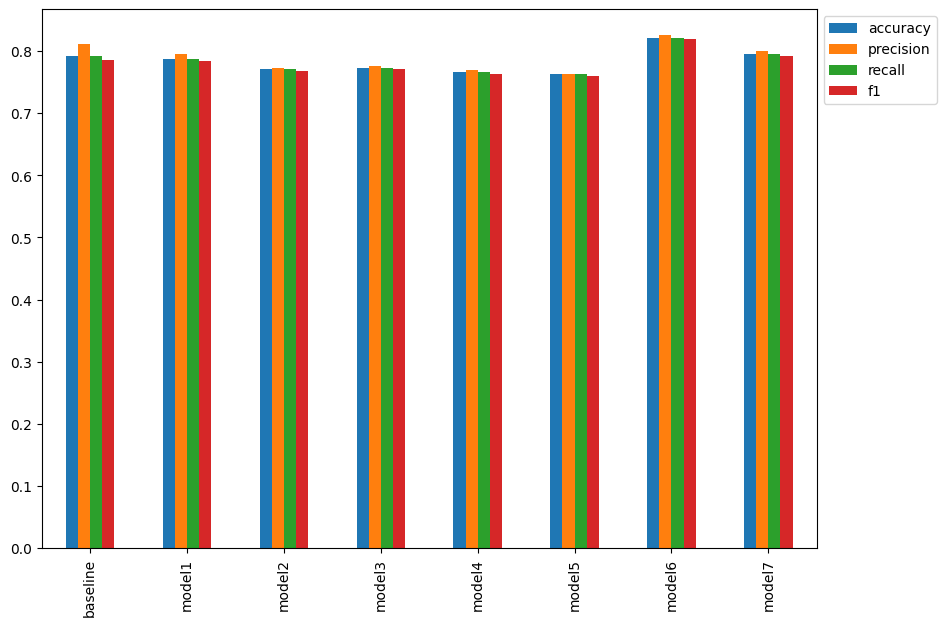

In [ ]:
all_model_results.plot(kind="bar",figsize=(10,7)).legend(bbox_to_anchor=(1.0,1.0));

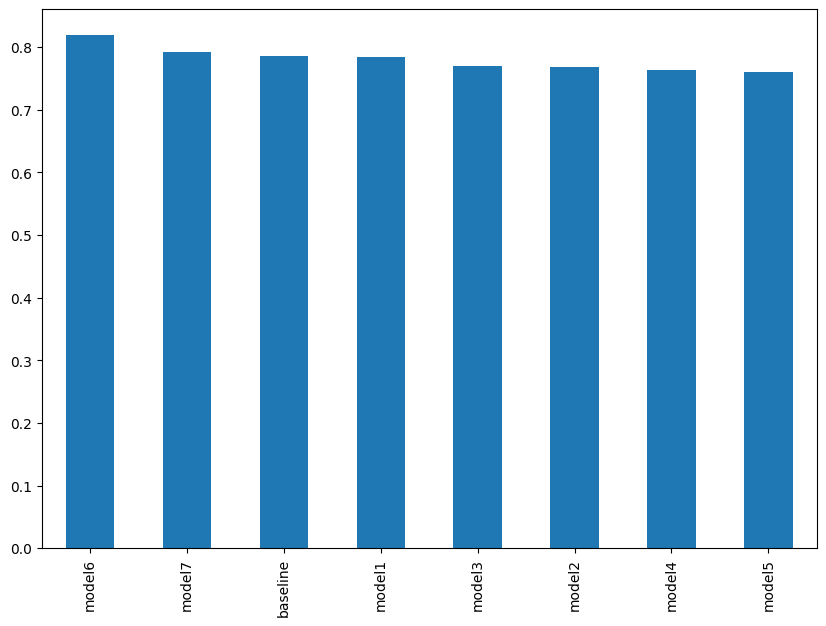

In [ ]:
all_model_results.sort_values("f1",ascending=False)["f1"].plot(kind="bar",figsize=(10,7));

In [ ]:
model6_pred_probs=model6.predict(val_sentences)
model6_preds=tf.squeeze(tf.round(model6_pred_probs))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# Create dataframe with validation sentences and best performing model predictions
val_df = pd.DataFrame({"text": val_sentences,
                       "target": val_label,
                       "pred": model6_preds,
                       "pred_prob": tf.squeeze(model6_pred_probs)})
val_df.head()

,text,target,pred,pred_prob
0,DFR EP016 Monthly Meltdown - On Dnbheaven 2015...,0,0.0,0.256484
1,FedEx no longer to transport bioterror germs i...,0,1.0,0.709217
2,Gunmen kill four in El Salvador bus attack: Su...,1,1.0,0.996663
3,@camilacabello97 Internally and externally scr...,1,0.0,0.089494
4,Radiation emergency #preparedness starts with ...,1,0.0,0.470071


In [ ]:
# Find the wrong predictions and sort by prediction probabilities
most_wrong = val_df[val_df["target"] != val_df["pred"]].sort_values("pred_prob", ascending=False)
most_wrong[:10]

,text,target,pred,pred_prob
49,@madonnamking RSPCA site multiple 7 story high...,0,1.0,0.969093
31,? High Skies - Burning Buildings ? http://t.co...,0,1.0,0.953331
628,@noah_anyname That's where the concentration c...,0,1.0,0.916150
393,@SonofLiberty357 all illuminated by the bright...,0,1.0,0.899647
119,@freefromwolves GodsLove &amp; #thankU brother...,0,1.0,0.875915
718,Haley Lu Richardson Fights for Water in The La...,0,1.0,0.859504
109,[55436] 1950 LIONEL TRAINS SMOKE LOCOMOTIVES W...,0,1.0,0.848745
303,Trafford Centre film fans angry after Odeon ci...,0,1.0,0.842062
759,FedEx will no longer transport bioterror patho...,0,1.0,0.823469
144,The Sound of Arson,0,1.0,0.810416


In [ ]:
# Check the false positives (model predicted 1 when should've been 0)
for row in most_wrong[:10].itertuples(): # loop through the top 10 rows (change the index to view different rows)
  _, text, target, pred, prob = row
  print(f"Target: {target}, Pred: {int(pred)}, Prob: {prob}")
  print(f"Text:\n{text}\n")
  print("----\n")

Target: 0, Pred: 1, Prob: 0.9690930247306824
Text:
@madonnamking RSPCA site multiple 7 story high rise buildings next to low density character residential in an area that floods

----

Target: 0, Pred: 1, Prob: 0.9533314108848572
Text:
? High Skies - Burning Buildings ? http://t.co/uVq41i3Kx2 #nowplaying

----

Target: 0, Pred: 1, Prob: 0.9161495566368103
Text:
@noah_anyname That's where the concentration camps and mass murder come in. 
 
EVERY. FUCKING. TIME.

----

Target: 0, Pred: 1, Prob: 0.8996466994285583
Text:
@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!

----

Target: 0, Pred: 1, Prob: 0.875914990901947
Text:
@freefromwolves GodsLove &amp; #thankU brother Danny for RT of NEW VIDEO http://t.co/cybKsXHF7d The Coming Apocalyptic US Earthquake &amp; Tsunami

----

Target: 0, Pred: 1, Prob: 0.8595041036605835
Text:
Haley Lu Richardson Fights for Water in The Last Survivors (Review) http://t.co/oObSCFOKtQ

----

Target: 0, Pred: 1, Prob: 0.8

In [ ]:
# Check the most wrong false negatives (model predicted 0 when should've predict 1)
for row in most_wrong[-10:].itertuples():
  _, text, target, pred, prob = row
  print(f"Target: {target}, Pred: {int(pred)}, Prob: {prob}")
  print(f"Text:\n{text}\n")
  print("----\n")

Target: 1, Pred: 0, Prob: 0.06722762435674667
Text:
I get to smoke my shit in peace

----

Target: 1, Pred: 0, Prob: 0.06547065079212189
Text:
If I fall is men GOD @Praiz8 is d bomb well av always known dat since 2008 bigger u I pray sir

----

Target: 1, Pred: 0, Prob: 0.06388480216264725
Text:
@willienelson We need help! Horses will die!Please RT &amp; sign petition!Take a stand &amp; be a voice for them! #gilbert23 https://t.co/e8dl1lNCVu

----

Target: 1, Pred: 0, Prob: 0.05028534308075905
Text:
Next May I'll be free...from school from obligations like family.... Best of all that damn curfew...

----

Target: 1, Pred: 0, Prob: 0.049719080328941345
Text:
Reddit Will Now QuarantineÛ_ http://t.co/pkUAMXw6pm #onlinecommunities #reddit #amageddon #freespeech #Business http://t.co/PAWvNJ4sAP

----

Target: 1, Pred: 0, Prob: 0.04393472149968147
Text:
@DavidVonderhaar At least you were sincere ??

----

Target: 1, Pred: 0, Prob: 0.024869466200470924
Text:
Why are you deluged with low self